# 🧾 The Tokenization Tax: A Deep Dive for Software Engineering Students

> *"Every word you send to an LLM has a price tag. Understanding how that price is calculated — and how to minimize it — is one of the most practical skills you can develop as an AI-era software engineer."*

---

## 📖 What This Notebook Covers

1. **What is Tokenization?** — The fundamental concept
2. **What is the Tokenization Tax?** — Where hidden cost comes from
3. **Key Vocabulary** — Terms you'll encounter in the real world
4. **Hands-on Experiments** — See it for yourself
5. **Real-World Scenarios** — When this matters most
6. **Optimization Strategies** — How to reduce the tax
7. **🎯 Exercise** — Your turn to practice

---

## 🏗️ Prerequisites

Before we start, let's install the libraries we need.

In [1]:
# Install required packages
# tiktoken  — OpenAI's tokenizer (works with GPT-3.5, GPT-4, Claude-compatible BPE analysis)
# matplotlib — for visualizations
# pandas     — for tabular comparisons
# numpy      — for numerical operations

!pip install tiktoken matplotlib pandas numpy --quiet

import tiktoken
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import json
import textwrap

print("✅ All libraries imported successfully!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ All libraries imported successfully!


---

## 📚 Part 1: What Is Tokenization?

When you send text to a Large Language Model (LLM) like GPT-4 or Claude, the model doesn't see individual **letters** or individual **words** — it sees **tokens**.

### 🔑 Definition: Token
> A **token** is a chunk of text that a language model treats as a single unit. It might be a whole word, part of a word, a punctuation mark, a space, or even a single character.

### Why Not Just Use Words?

Good question! Using whole words has problems:
- The vocabulary would be **enormous** (millions of entries for every language)
- **Rare words** and **typos** would be unknown to the model
- **New words** (slang, technical terms) couldn't be handled

Using individual characters also has problems:
- The **sequences would be very long**, making the model slow and expensive
- It would be hard to learn **word-level meaning**

**Tokens are the sweet spot.** The most common tokenization algorithm used today is called **BPE (Byte Pair Encoding)**.

### 🔑 Definition: BPE (Byte Pair Encoding)
> **BPE** is an algorithm that starts with individual characters, then iteratively **merges the most frequent pairs** of symbols together. Common words end up as single tokens; rare words get split into sub-word pieces.

Let's see this in action:

In [7]:
# Load the cl100k_base encoder — this is used by GPT-4 and is similar to what modern LLMs use
# 'cl100k_base' means: 'cl' (context length), '100k' (100,000 token vocabulary), 'base' (base model)
enc = tiktoken.get_encoding("cl100k_base")

def tokenize_and_display(text, label=""):
    """Tokenize text and display each token with its ID."""
    tokens = enc.encode(text)
    token_strings = [enc.decode([t]) for t in tokens]
    
    print(f"{'='*60}")
    if label:
        print(f"📝 {label}")
    print(f"Input text : '{text}'")
    print(f"Token count: {len(tokens)}")
    print(f"{'─'*60}")
    print(f"{'Token String':<25} {'Token ID':<10}")
    print(f"{'─'*60}")
    for ts, tid in zip(token_strings, tokens):
        # Show whitespace clearly
        display_ts = ts.replace(" ", "·").replace("\n", "↵")
        print(f"  {repr(display_ts):<23} {tid:<10}")
    print()

# Let's tokenize some simple examples
tokenize_and_display("Hello", "A simple word")
tokenize_and_display("Hello world", "Two words")
tokenize_and_display("tokenization", "A longer word")

📝 A simple word
Input text : 'Hello'
Token count: 1
────────────────────────────────────────────────────────────
Token String              Token ID  
────────────────────────────────────────────────────────────
  'Hello'                 9906      

📝 Two words
Input text : 'Hello world'
Token count: 2
────────────────────────────────────────────────────────────
Token String              Token ID  
────────────────────────────────────────────────────────────
  'Hello'                 9906      
  '·world'                1917      

📝 A longer word
Input text : 'tokenization'
Token count: 2
────────────────────────────────────────────────────────────
Token String              Token ID  
────────────────────────────────────────────────────────────
  'token'                 5963      
  'ization'               2065      



### 🔎 Observation

Notice a few things:
- `"Hello"` is **one token** (it's common enough)
- `"Hello world"` — notice that `" world"` (with the leading space) is also one token! **Spaces are baked into tokens.**
- `"tokenization"` might be split into **multiple tokens** because it's less common

Now let's look at something more revealing — **numbers**:

In [8]:
# Numbers are particularly interesting for tokenization
examples = [
    ("1", "Single digit"),
    ("42", "Two-digit number"),
    ("2024", "Year"),
    ("1000000", "One million"),
    ("3.14159265358979", "Pi to many decimals"),
    ("192.168.1.1", "IP address"),
]

print("📊 How Numbers Are Tokenized")
print("="*50)
for text, label in examples:
    tokens = enc.encode(text)
    token_strings = [enc.decode([t]) for t in tokens]
    print(f"  {label:<30} → {len(tokens)} token(s): {token_strings}")

📊 How Numbers Are Tokenized
  Single digit                   → 1 token(s): ['1']
  Two-digit number               → 1 token(s): ['42']
  Year                           → 2 token(s): ['202', '4']
  One million                    → 3 token(s): ['100', '000', '0']
  Pi to many decimals            → 7 token(s): ['3', '.', '141', '592', '653', '589', '79']
  IP address                     → 7 token(s): ['192', '.', '168', '.', '1', '.', '1']


### 🔎 Key Insight About Numbers

Large numbers and decimals get split into **many tokens**. This has two consequences:
1. **Cost**: More tokens = more money
2. **Accuracy**: LLMs are notoriously bad at math partly because numbers get fragmented into tokens that don't carry numeric meaning!

---

## 💰 Part 2: The Tokenization Tax

Now that you understand tokens, let's talk about the **Tokenization Tax** — the central concept of this notebook.

### 🔑 Definition: Tokenization Tax
> The **Tokenization Tax** refers to the **hidden computational and financial overhead** incurred when text is converted into tokens. Specifically, it describes the phenomenon where certain types of content — code, JSON, numbers, non-English text, verbose prompts — generate **disproportionately more tokens** than their semantic information content would suggest, inflating both cost and latency.

Think of it like a **currency exchange fee**. You might exchange \$100, but after fees, the recipient gets \$92. Similarly, you might *feel* like you're sending "a short message", but the LLM sees far more tokens than you'd expect.

### Where Does the Tax Come From?

| Source | Why It Inflates Tokens |
|--------|------------------------|
| **Structured data (JSON/XML)** | Punctuation (`{`, `}`, `"`, `:`) each consume tokens |
| **Code** | Special symbols, indentation spaces |
| **Numbers** | Long numbers get split digit-by-digit |
| **Non-English text** | Non-Latin scripts are tokenized less efficiently |
| **Verbose prompts** | Politeness, redundancy, and filler words |
| **Whitespace / formatting** | Markdown, extra newlines, decorative dashes |

### Why Should You Care?

LLM APIs charge **per token** — both for **input** (your prompt) and **output** (the model's response). As of 2024/2025:
- GPT-4 costs ~\$10–\$30 per million tokens
- At scale (millions of requests/day), poor token efficiency can cost **thousands of dollars per month**
- Tokens also affect **latency** — more tokens = slower responses
- Models have a **context window limit** — wasteful tokens eat into how much data you can send

Let's see this in action:

In [9]:
# =====================================================
# EXPERIMENT 1: The JSON Tax
# The same information, encoded different ways
# =====================================================

# Raw semantic content: a user's profile
data_as_plain_english = "User Alice is 28 years old, from New York, and works as an engineer."

data_as_json_pretty = """{
    "name": "Alice",
    "age": 28,
    "city": "New York",
    "occupation": "engineer"
}"""

data_as_json_compact = '{"name":"Alice","age":28,"city":"New York","occupation":"engineer"}'

data_as_csv = "Alice,28,New York,engineer"

formats = {
    "Plain English": data_as_plain_english,
    "Pretty JSON": data_as_json_pretty,
    "Compact JSON": data_as_json_compact,
    "CSV": data_as_csv,
}

print("📊 EXPERIMENT 1: The Same Data, Different Formats")
print("="*60)
print(f"{'Format':<20} {'Chars':<10} {'Tokens':<10} {'Chars/Token'}")
print("─"*60)

results = {}
for name, text in formats.items():
    tokens = enc.encode(text)
    char_count = len(text)
    token_count = len(tokens)
    ratio = char_count / token_count
    results[name] = {"chars": char_count, "tokens": token_count, "ratio": ratio}
    print(f"  {name:<18} {char_count:<10} {token_count:<10} {ratio:.2f}")

print()
baseline = results["CSV"]["tokens"]
print("💡 Relative token cost (vs CSV baseline):")
for name, r in results.items():
    overhead = ((r['tokens'] - baseline) / baseline) * 100
    sign = '+' if overhead >= 0 else ''
    bar = '█' * int(abs(overhead) / 5) if overhead > 0 else ''
    print(f"  {name:<20} {sign}{overhead:+.0f}%  {bar}")

📊 EXPERIMENT 1: The Same Data, Different Formats
Format               Chars      Tokens     Chars/Token
────────────────────────────────────────────────────────────
  Plain English      68         18         3.78
  Pretty JSON        92         32         2.88
  Compact JSON       67         19         3.53
  CSV                26         9          2.89

💡 Relative token cost (vs CSV baseline):
  Plain English        ++100%  ████████████████████
  Pretty JSON          ++256%  ███████████████████████████████████████████████████
  Compact JSON         ++111%  ██████████████████████
  CSV                  ++0%  


In [10]:
# =====================================================
# EXPERIMENT 2: The Prompt Verbosity Tax
# How much does politeness cost you?
# =====================================================

task_verbose = """Hello! I hope you are doing well today. I would really appreciate it if you 
could help me with something. I need you to please carefully read the following 
text and then kindly provide a brief summary. The text is as follows: 
\"The mitochondria is the powerhouse of the cell.\"
Thank you so much for your assistance, I really appreciate your help!"""

task_normal = """Please summarize the following text:
\"The mitochondria is the powerhouse of the cell.\""""

task_terse = 'Summarize: "The mitochondria is the powerhouse of the cell."'

task_minimal = 'Summarize in one sentence: mitochondria powerhouse cell'

prompts = {
    "Over-polite": task_verbose,
    "Normal": task_normal,
    "Terse": task_terse,
    "Minimal (lossy)": task_minimal,
}

print("📊 EXPERIMENT 2: Prompt Verbosity Tax")
print("="*60)
print(f"{'Style':<20} {'Tokens':<10} {'Cost @ $0.01/1K tokens'}")
print("─"*60)

PRICE_PER_1K = 0.01  # Example pricing in USD

for name, text in prompts.items():
    tokens = enc.encode(text)
    cost = (len(tokens) / 1000) * PRICE_PER_1K
    print(f"  {name:<18} {len(tokens):<10} ${cost:.6f}")

print()
print("💡 At 1 million API calls/day, the difference between")
over_polite = len(enc.encode(task_verbose))
normal = len(enc.encode(task_normal))
diff_per_call = (over_polite - normal) / 1000 * PRICE_PER_1K
diff_daily = diff_per_call * 1_000_000
diff_monthly = diff_daily * 30
print(f"  'Over-polite' and 'Normal' prompts is:")
print(f"  ${diff_daily:.2f}/day  →  ${diff_monthly:.2f}/month")

📊 EXPERIMENT 2: Prompt Verbosity Tax
Style                Tokens     Cost @ $0.01/1K tokens
────────────────────────────────────────────────────────────
  Over-polite        74         $0.000740
  Normal             16         $0.000160
  Terse              15         $0.000150
  Minimal (lossy)    11         $0.000110

💡 At 1 million API calls/day, the difference between
  'Over-polite' and 'Normal' prompts is:
  $580.00/day  →  $17400.00/month


---

## 🌍 Part 3: The Language Tax

One of the most **overlooked** aspects of the tokenization tax is how it affects **non-English languages** — and this is especially important if you're building products for **African, Asian, or Middle Eastern markets**.

### Why Are Some Languages More Expensive?

Tokenizers like BPE are **trained on internet text**, which is **heavily English-biased**. This means:
- English words are highly optimized (whole words = 1 token)
- Languages like **Swahili, Arabic, Chinese, Hindi** get tokenized less efficiently
- The same semantic content costs **2–5× more tokens** in some languages

This is sometimes called **"tokenizer inequality"** or the **"language tax"**.

In [11]:
# =====================================================
# EXPERIMENT 3: The Language Tax
# Same sentence in different languages
# =====================================================

# Approximate translations of: "The weather is nice today, I will go to the market."
same_sentence_different_languages = {
    "English":    "The weather is nice today, I will go to the market.",
    "French":     "Il fait beau aujourd'hui, j'irai au marché.",
    "Spanish":    "El tiempo es bueno hoy, iré al mercado.",
    "Swahili":    "Hali ya hewa ni nzuri leo, nitaenda sokoni.",
    "Arabic":     "الطقس جميل اليوم، سأذهب إلى السوق.",
    "Chinese":    "今天天气很好，我要去市场。",
    "Hindi":      "आज मौसम अच्छा है, मैं बाज़ार जाऊँगा।",
    "Japanese":   "今日は天気がいいので、市場に行きます。",
}

print("📊 EXPERIMENT 3: Language Tokenization Efficiency")
print("="*65)
print(f"{'Language':<12} {'Chars':<8} {'Tokens':<9} {'Chars/Token':<14} {'Relative Cost'}")
print("─"*65)

english_tokens = len(enc.encode(same_sentence_different_languages["English"]))

lang_data = {}
for lang, text in same_sentence_different_languages.items():
    tokens = enc.encode(text)
    tc = len(tokens)
    cc = len(text)
    ratio = cc / tc
    relative = tc / english_tokens
    lang_data[lang] = {"tokens": tc, "chars": cc, "ratio": ratio, "relative": relative}
    bar = "█" * int(relative * 5)
    print(f"  {lang:<12} {cc:<8} {tc:<9} {ratio:<14.2f} {relative:.2f}x  {bar}")

print()
print("⚠️  A 2.0x relative cost means: same sentence costs TWICE as many tokens!")
print("   This directly translates to 2x the API cost for non-English products.")

📊 EXPERIMENT 3: Language Tokenization Efficiency
Language     Chars    Tokens    Chars/Token    Relative Cost
─────────────────────────────────────────────────────────────────
  English      51       13        3.92           1.00x  █████
  French       43       13        3.31           1.00x  █████
  Spanish      39       11        3.55           0.85x  ████
  Swahili      43       17        2.53           1.31x  ██████
  Arabic       34       24        1.42           1.85x  █████████
  Chinese      13       15        0.87           1.15x  █████
  Hindi        36       43        0.84           3.31x  ████████████████
  Japanese     19       18        1.06           1.38x  ██████

⚠️  A 2.0x relative cost means: same sentence costs TWICE as many tokens!
   This directly translates to 2x the API cost for non-English products.


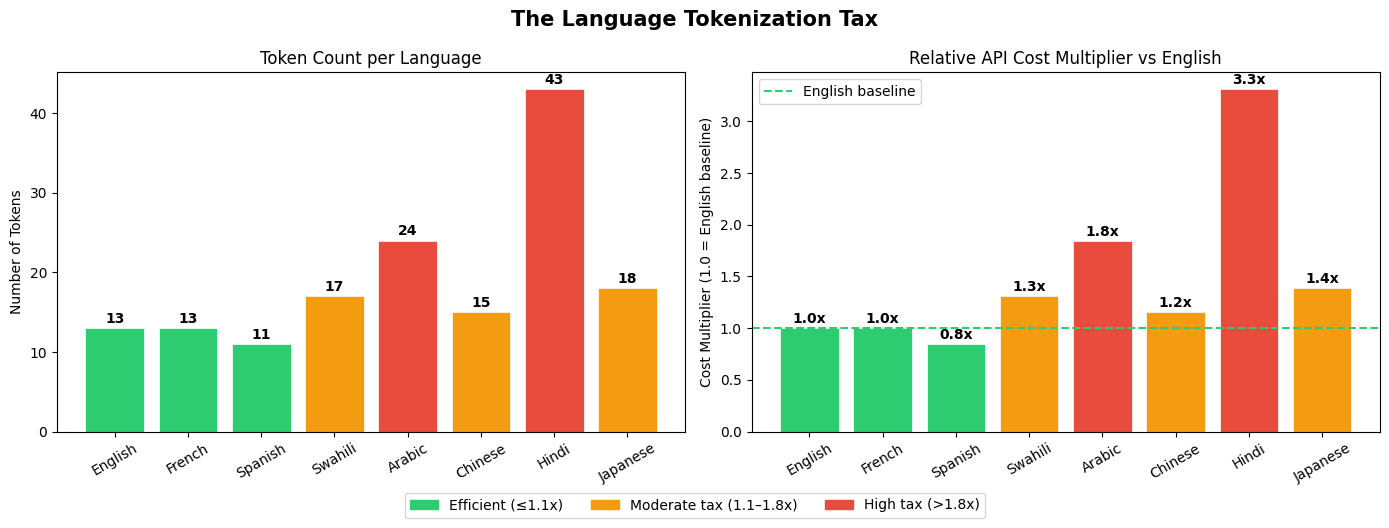

📊 Chart saved!


In [16]:
# Visualize the language tax
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("The Language Tokenization Tax", fontsize=15, fontweight='bold')

langs = list(lang_data.keys())
tokens = [lang_data[l]["tokens"] for l in langs]
relatives = [lang_data[l]["relative"] for l in langs]
colors = ["#2ecc71" if r <= 1.1 else "#f39c12" if r <= 1.8 else "#e74c3c" for r in relatives]

# Plot 1: Token counts
bars = axes[0].bar(langs, tokens, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title("Token Count per Language", fontsize=12)
axes[0].set_ylabel("Number of Tokens")
axes[0].tick_params(axis='x', rotation=30)
for bar, token in zip(bars, tokens):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(token), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Relative cost multiplier
bars2 = axes[1].bar(langs, relatives, color=colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=1.0, color='#2ecc71', linestyle='--', linewidth=1.5, label='English baseline')
axes[1].set_title("Relative API Cost Multiplier vs English", fontsize=12)
axes[1].set_ylabel("Cost Multiplier (1.0 = English baseline)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
for bar, rel in zip(bars2, relatives):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{rel:.1f}x", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend
green_patch = mpatches.Patch(color='#2ecc71', label='Efficient (≤1.1x)')
orange_patch = mpatches.Patch(color='#f39c12', label='Moderate tax (1.1–1.8x)')
red_patch = mpatches.Patch(color='#e74c3c', label='High tax (>1.8x)')
fig.legend(handles=[green_patch, orange_patch, red_patch],
           loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('experiment_outputs/language_tax.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Chart saved!")

---

## 💻 Part 4: The Code & Structured Data Tax

As a software engineer, you'll frequently need to **pass code or data structures** to LLMs — for code review, SQL generation, data analysis, etc.

Understanding how **code tokenizes** helps you write better prompts and system designs.

### 🔑 Key Terms

- **Context Window**: The maximum number of tokens an LLM can process at once (input + output). GPT-4 has 128K tokens; Claude has up to 200K. Wasting tokens = wasting context space.
- **Prompt Engineering**: The practice of designing inputs to LLMs to get optimal outputs — including token efficiency.
- **System Prompt**: Instructions sent before the user's message, typically used for configuration. Every word here costs tokens on **every API call**.
- **Token Budget**: A cap on the number of tokens used in a prompt or conversation, often set to control costs.

In [17]:
# =====================================================
# EXPERIMENT 4: Code Tokenization
# How does code style affect token count?
# =====================================================

# Same algorithm, different coding styles
code_verbose = '''
def calculate_the_sum_of_all_numbers_in_a_list(input_list_of_numbers):
    """
    This function takes a list of numbers as input and calculates
    the total sum of all the numbers in the list.
    
    Parameters:
    -----------
    input_list_of_numbers : list
        A list containing numerical values
        
    Returns:
    --------
    int or float
        The total sum of all numbers in the list
    """
    total_sum_accumulator = 0
    for each_individual_number in input_list_of_numbers:
        total_sum_accumulator = total_sum_accumulator + each_individual_number
    return total_sum_accumulator
'''

code_standard = '''
def sum_numbers(numbers):
    """Return the sum of all numbers in the list."""
    total = 0
    for n in numbers:
        total += n
    return total
'''

code_minimal = 'def sum_numbers(nums): return sum(nums)'

code_samples = {
    "Verbose (with full docstring)": code_verbose,
    "Standard (short docstring)": code_standard,
    "Minimal (one-liner)": code_minimal,
}

print("📊 EXPERIMENT 4: Code Style vs Token Count")
print("="*60)
print(f"{'Style':<30} {'Tokens':<10} {'Lines':<10}")
print("─"*60)

for name, code in code_samples.items():
    tokens = enc.encode(code)
    lines = len(code.strip().split('\n'))
    print(f"  {name:<28} {len(tokens):<10} {lines}")

print()
print("⚠️  The verbose version uses significantly more tokens than the minimal version")
v = len(enc.encode(code_verbose))
m = len(enc.encode(code_minimal))
print(f"   Verbose: {v} tokens | Minimal: {m} tokens | Ratio: {v/m:.1f}x more tokens")
print()
print("💡 When passing code to an LLM API, you usually DON'T need full docstrings.")
print("   Strip comments and docstrings from code you send as context to save tokens!")

📊 EXPERIMENT 4: Code Style vs Token Count
Style                          Tokens     Lines     
────────────────────────────────────────────────────────────
  Verbose (with full docstring) 129        19
  Standard (short docstring)   39         6
  Minimal (one-liner)          9          1

⚠️  The verbose version uses significantly more tokens than the minimal version
   Verbose: 129 tokens | Minimal: 9 tokens | Ratio: 14.3x more tokens

💡 When passing code to an LLM API, you usually DON'T need full docstrings.
   Strip comments and docstrings from code you send as context to save tokens!


In [18]:
# =====================================================
# EXPERIMENT 5: The System Prompt Multiplier Effect
# System prompts run on EVERY call — small savings = huge savings at scale
# =====================================================

system_prompt_verbose = """
You are a very helpful, knowledgeable, and friendly AI assistant. Your primary role is to 
assist users with their questions and provide accurate, detailed, and comprehensive answers. 
Please always be polite and professional in your responses. You should strive to be 
informative, helpful, and concise when appropriate. Always make sure to address the user's 
question directly and provide relevant information. If you don't know something, please 
say so honestly rather than making up information. Be sure to ask clarifying questions 
if the user's request is unclear. Format your responses clearly and in an easy-to-read manner.
"""

system_prompt_concise = """
You are a helpful AI assistant. Answer questions accurately and concisely. 
Say "I don't know" if uncertain. Ask for clarification if needed.
"""

system_prompt_minimal = "Helpful AI. Be accurate and concise."

system_prompts = {
    "Verbose": system_prompt_verbose,
    "Concise": system_prompt_concise, 
    "Minimal": system_prompt_minimal,
}

PRICE_PER_1M_INPUT = 10.00  # USD, GPT-4 approximate pricing
DAILY_CALLS = 100_000

print("📊 EXPERIMENT 5: System Prompt Multiplier Effect")
print(f"    Scenario: {DAILY_CALLS:,} API calls/day at ${PRICE_PER_1M_INPUT}/M tokens")
print("="*70)
print(f"{'Style':<12} {'Tokens':<10} {'Daily Cost':<15} {'Monthly Cost':<15} {'Yearly Cost'}")
print("─"*70)

for name, prompt in system_prompts.items():
    tokens = len(enc.encode(prompt))
    daily_tokens = tokens * DAILY_CALLS
    daily_cost = (daily_tokens / 1_000_000) * PRICE_PER_1M_INPUT
    monthly_cost = daily_cost * 30
    yearly_cost = daily_cost * 365
    print(f"  {name:<10} {tokens:<10} ${daily_cost:<14.2f} ${monthly_cost:<14.2f} ${yearly_cost:.2f}")

print()
verbose_tokens = len(enc.encode(system_prompt_verbose))
minimal_tokens = len(enc.encode(system_prompt_minimal))
saved_per_call = verbose_tokens - minimal_tokens
saved_monthly = (saved_per_call * DAILY_CALLS * 30 / 1_000_000) * PRICE_PER_1M_INPUT
print(f"💰 Switching from Verbose → Minimal saves ~{saved_per_call} tokens/call")
print(f"   That's ${saved_monthly:,.2f}/month in savings!")

📊 EXPERIMENT 5: System Prompt Multiplier Effect
    Scenario: 100,000 API calls/day at $10.0/M tokens
Style        Tokens     Daily Cost      Monthly Cost    Yearly Cost
──────────────────────────────────────────────────────────────────────
  Verbose    124        $124.00         $3720.00        $45260.00
  Concise    33         $33.00          $990.00         $12045.00
  Minimal    9          $9.00           $270.00         $3285.00

💰 Switching from Verbose → Minimal saves ~115 tokens/call
   That's $3,450.00/month in savings!


---

## 🗺️ Part 5: Real-World Scenarios Where This Matters

### Scenario 1: 🛒 E-commerce Chatbot
You're building a product recommendation chatbot. Your system prompt includes the entire product catalog as JSON. With 10,000 products, each with 15 fields...

**The Tax**: Pretty-printed JSON can use 2–3× more tokens than compact JSON. A 500K token catalog becomes 1M+ tokens.

**The Fix**: Use compact JSON, abbreviate field names, or better yet — use a vector database and retrieve only relevant items.

### Scenario 2: 🏦 Financial Data Analysis
Your app sends stock prices and financial data to an LLM for analysis.

**The Tax**: Numbers like `1234567.89` can tokenize to 5–6 tokens. A table of 100 prices = hundreds of extra tokens.

**The Fix**: Round numbers where possible, use descriptive aggregates instead of raw data (e.g., "Q3 revenue was $2.1M, up 15% YoY" instead of a full table).

### Scenario 3: 🌍 Multilingual Customer Support (Uganda / East Africa context)
You're building an AI support tool for users in Uganda who speak Swahili, Luganda, or Kinyarwanda.

**The Tax**: These languages can tokenize at 2–4× the rate of English. Your costs are not what you budgeted.

**The Fix**: Profile tokenization costs per language during development. Consider language-specific models when they exist.

### Scenario 4: 📄 Document Processing Pipeline
You're building a RAG (Retrieval-Augmented Generation) system that passes documents to an LLM.

**The Tax**: Raw PDFs often contain headers, footers, page numbers, and whitespace that inflate token count without adding meaning.

**The Fix**: Pre-process documents to strip irrelevant content before tokenizing.

In [19]:
# =====================================================
# EXPERIMENT 6: RAG Document Preprocessing Tax
# =====================================================

# Simulated raw extracted PDF text (with all the junk)
raw_document = """
                        ACME CORPORATION
                     QUARTERLY EARNINGS REPORT
                          Q3 2024
================================================================
                                                          Page 1
----------------------------------------------------------------


SECTION 1: EXECUTIVE SUMMARY
----------------------------------------------------------------

Total Revenue.....................................$2,145,000.00
Operating Expenses................................$1,234,567.89
Net Profit........................................$  910,432.11
Profit Margin....................................       42.45%


Note: All figures are in USD. See appendix for full breakdown.
For questions contact: finance@acme.com | Tel: +1-555-0192
================================================================
                                                          Page 2
"""

# Cleaned version — only the semantically useful content
cleaned_document = """
ACME Corp Q3 2024: Revenue $2.15M, Expenses $1.23M, Net Profit $910K (42.5% margin).
"""

raw_tokens = enc.encode(raw_document)
clean_tokens = enc.encode(cleaned_document)

print("📊 EXPERIMENT 6: Document Preprocessing Reduces Token Tax")
print("="*55)
print(f"  Raw document   : {len(raw_tokens):>5} tokens")
print(f"  Cleaned version: {len(clean_tokens):>5} tokens")
reduction = (1 - len(clean_tokens) / len(raw_tokens)) * 100
print(f"  Reduction      : {reduction:.1f}%")
print()
print("💡 At scale: if you process 10,000 documents/day...")
daily_raw = len(raw_tokens) * 10_000
daily_clean = len(clean_tokens) * 10_000
price_per_m = 10.0
print(f"   Raw  : {daily_raw:>10,} tokens → ${(daily_raw/1e6)*price_per_m:.2f}/day")
print(f"   Clean: {daily_clean:>10,} tokens → ${(daily_clean/1e6)*price_per_m:.2f}/day")
print(f"   Savings: ${((daily_raw - daily_clean)/1e6)*price_per_m:.2f}/day = ${((daily_raw - daily_clean)/1e6)*price_per_m*30:.2f}/month")

📊 EXPERIMENT 6: Document Preprocessing Reduces Token Tax
  Raw document   :   133 tokens
  Cleaned version:    36 tokens
  Reduction      : 72.9%

💡 At scale: if you process 10,000 documents/day...
   Raw  :  1,330,000 tokens → $13.30/day
   Clean:    360,000 tokens → $3.60/day
   Savings: $9.70/day = $291.00/month


---

## 🛠️ Part 6: Strategies to Reduce the Tokenization Tax

Here's your **engineer's playbook** for minimizing the tokenization tax:

| Strategy | Technique | Expected Savings |
|----------|-----------|------------------|
| **Compact data formats** | Use compact JSON instead of pretty-printed | 20–40% |
| **Abbreviate field names** | `{"n":"Alice","a":28}` vs `{"name":"Alice","age":28}` | 10–30% |
| **Trim system prompts** | Remove filler words and redundancy | 30–60% |
| **Strip code comments** | Remove docstrings before sending code | 20–50% |
| **Round numbers** | 1234567.89 → 1.23M | 50–80% on numeric data |
| **Summarize before sending** | Pre-summarize long documents | 60–90% |
| **Use RAG** | Retrieve only relevant chunks | 70–95% |
| **Prompt caching** | Cache repeated prompt prefixes (Anthropic, OpenAI feature) | 90% on cached portion |

Let's test a few of these:

In [ ]:
# =====================================================
# EXPERIMENT 7: JSON Key Abbreviation Strategy
# =====================================================

import json

# Simulate a list of user records being sent to an LLM
users_verbose = [
    {"user_id": 1, "first_name": "Alice", "last_name": "Johnson", "email_address": "alice@example.com",
     "account_status": "active", "subscription_plan": "premium", "total_purchases": 1542.50},
    {"user_id": 2, "first_name": "Bob", "last_name": "Smith", "email_address": "bob@example.com",
     "account_status": "inactive", "subscription_plan": "free", "total_purchases": 0.0},
    {"user_id": 3, "first_name": "Carol", "last_name": "Williams", "email_address": "carol@example.com",
     "account_status": "active", "subscription_plan": "basic", "total_purchases": 234.00},
]

# Same data with abbreviated keys
users_compact = [
    {"id": 1, "fn": "Alice", "ln": "Johnson", "em": "alice@example.com",
     "st": "active", "plan": "premium", "spend": 1542.5},
    {"id": 2, "fn": "Bob", "ln": "Smith", "em": "bob@example.com",
     "st": "inactive", "plan": "free", "spend": 0},
    {"id": 3, "fn": "Carol", "ln": "Williams", "em": "carol@example.com",
     "st": "active", "plan": "basic", "spend": 234},
]

formats_to_compare = {
    "Pretty JSON (verbose keys)": json.dumps(users_verbose, indent=2),
    "Compact JSON (verbose keys)": json.dumps(users_verbose, separators=(',', ':')),
    "Compact JSON (short keys)": json.dumps(users_compact, separators=(',', ':')),
}

print("📊 EXPERIMENT 7: JSON Optimization Strategies")
print("="*60)
print(f"{'Format':<35} {'Tokens':<10} {'Savings vs baseline'}")
print("─"*60)

baseline = None
for name, text in formats_to_compare.items():
    tokens = len(enc.encode(text))
    if baseline is None:
        baseline = tokens
        savings = "(baseline)"
    else:
        pct = (1 - tokens/baseline) * 100
        savings = f"−{pct:.0f}% ({baseline - tokens} fewer tokens)"
    print(f"  {name:<33} {tokens:<10} {savings}")

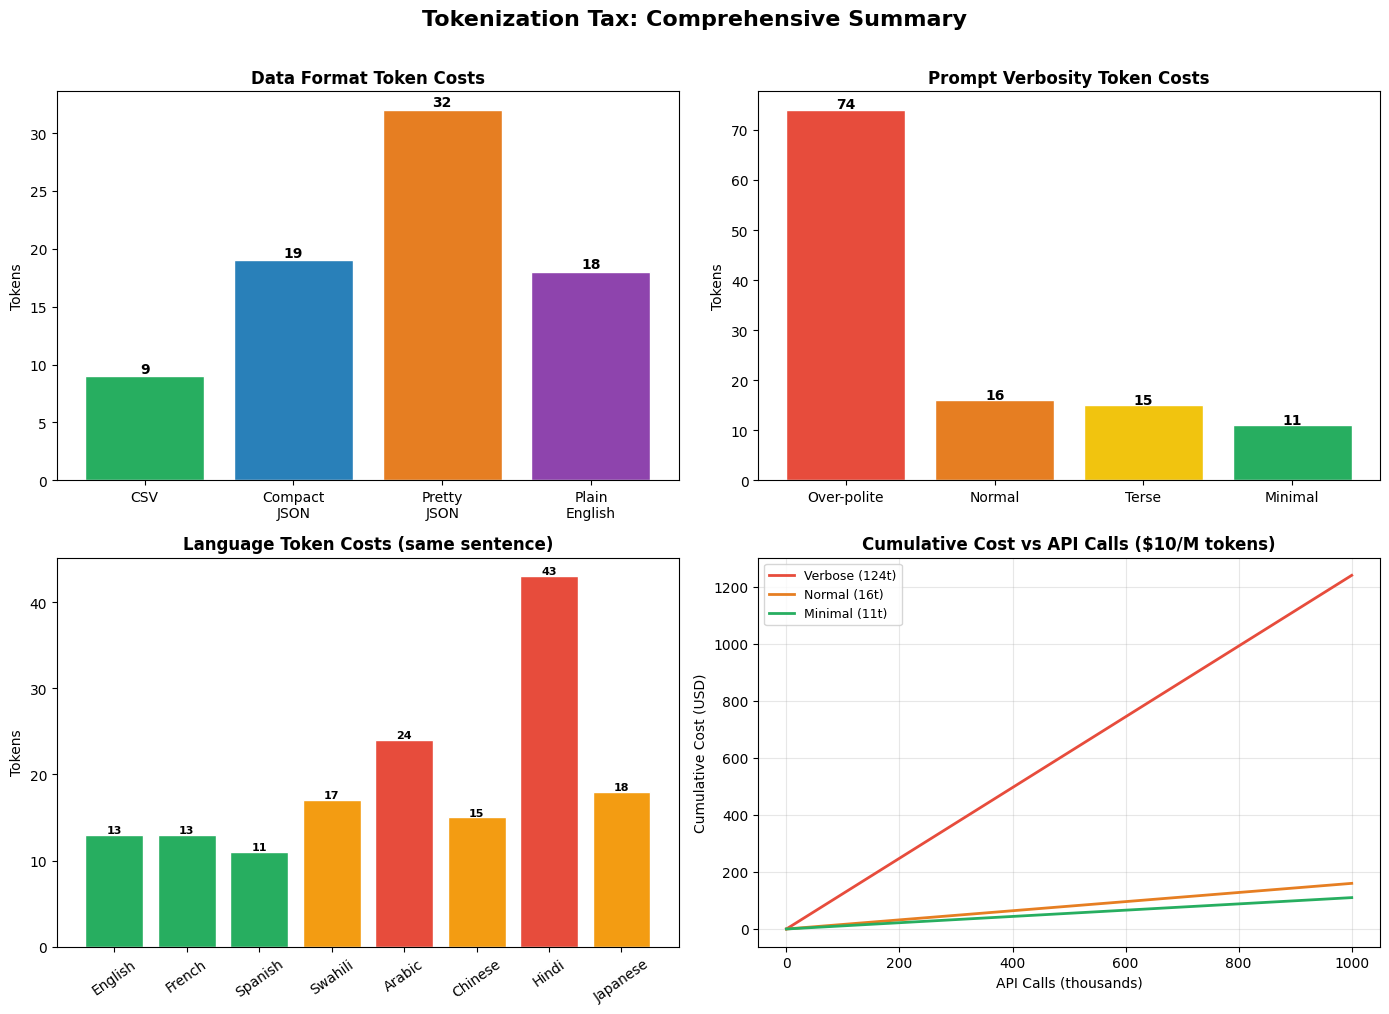

📊 Summary dashboard saved!


In [21]:
# =====================================================
# COMPREHENSIVE VISUALIZATION: Token Tax Summary Dashboard
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tokenization Tax: Comprehensive Summary", fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Format comparison ---
ax1 = axes[0, 0]
format_names = ["CSV", "Compact\nJSON", "Pretty\nJSON", "Plain\nEnglish"]
format_tokens = [
    len(enc.encode(data_as_csv)),
    len(enc.encode(data_as_json_compact)),
    len(enc.encode(data_as_json_pretty)),
    len(enc.encode(data_as_plain_english)),
]
colors1 = ["#27ae60", "#2980b9", "#e67e22", "#8e44ad"]
bars1 = ax1.bar(format_names, format_tokens, color=colors1, edgecolor='white')
ax1.set_title("Data Format Token Costs", fontweight='bold')
ax1.set_ylabel("Tokens")
for bar, val in zip(bars1, format_tokens):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

# --- Chart 2: Prompt verbosity ---
ax2 = axes[0, 1]
prompt_names = ["Over-polite", "Normal", "Terse", "Minimal"]
prompt_tokens = [len(enc.encode(p)) for p in [task_verbose, task_normal, task_terse, task_minimal]]
colors2 = ["#e74c3c", "#e67e22", "#f1c40f", "#27ae60"]
bars2 = ax2.bar(prompt_names, prompt_tokens, color=colors2, edgecolor='white')
ax2.set_title("Prompt Verbosity Token Costs", fontweight='bold')
ax2.set_ylabel("Tokens")
for bar, val in zip(bars2, prompt_tokens):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

# --- Chart 3: Language tax ---
ax3 = axes[1, 0]
top_langs = list(lang_data.keys())
lang_tok = [lang_data[l]["tokens"] for l in top_langs]
lang_colors = ["#27ae60" if lang_data[l]["relative"] <= 1.1
               else "#f39c12" if lang_data[l]["relative"] <= 1.8
               else "#e74c3c" for l in top_langs]
bars3 = ax3.bar(top_langs, lang_tok, color=lang_colors, edgecolor='white')
ax3.set_title("Language Token Costs (same sentence)", fontweight='bold')
ax3.set_ylabel("Tokens")
ax3.tick_params(axis='x', rotation=35)
for bar, val in zip(bars3, lang_tok):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', fontsize=8, fontweight='bold')

# --- Chart 4: Cumulative cost at scale ---
ax4 = axes[1, 1]
calls = np.arange(0, 1_000_001, 10_000)
price_per_token = 10 / 1_000_000  # $10 per million

ax4.plot(calls/1000, calls * verbose_tokens/1e6 * 10, label=f'Verbose ({verbose_tokens}t)', color='#e74c3c', linewidth=2)
ax4.plot(calls/1000, calls * len(enc.encode(task_normal))/1e6 * 10, label=f'Normal ({len(enc.encode(task_normal))}t)', color='#e67e22', linewidth=2)
ax4.plot(calls/1000, calls * len(enc.encode(task_minimal))/1e6 * 10, label=f'Minimal ({len(enc.encode(task_minimal))}t)', color='#27ae60', linewidth=2)
ax4.set_title("Cumulative Cost vs API Calls ($10/M tokens)", fontweight='bold')
ax4.set_xlabel("API Calls (thousands)")
ax4.set_ylabel("Cumulative Cost (USD)")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_outputs/token_tax_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Summary dashboard saved!")

---

## 🎯 Part 7: EXERCISES

Now it's your turn! Complete the following exercises to solidify your understanding.

### 📝 Exercise 1: Token Counter Utility

**Task**: Complete the `TokenBudgetManager` class below. It should:
- Accept a maximum token budget
- Let you add text items (e.g., system prompt, user message, context chunks)
- Warn you when you're approaching the limit
- Reject additions that would exceed the budget
- Report remaining budget at any point

**Hint**: Use `enc.encode(text)` to count tokens.

In [ ]:
# ============================================================
# EXERCISE 1: Complete the TokenBudgetManager class
# ============================================================

class TokenBudgetManager:
    """Manages a token budget for LLM API calls."""
    
    def __init__(self, max_tokens: int, warning_threshold: float = 0.8):
        """
        Initialize the budget manager.
        
        Args:
            max_tokens: Maximum number of tokens allowed
            warning_threshold: Fraction of budget at which to warn (default 80%)
        """
        self.max_tokens = max_tokens
        self.warning_threshold = warning_threshold
        self.items = []  # List of (name, token_count) tuples
        # TODO: Initialize any other attributes you need
        
    def add_text(self, name: str, text: str) -> bool:
        """
        Try to add a text item to the budget.
        
        TODO: Implement this method:
        1. Count tokens in `text`
        2. Check if adding it would exceed max_tokens
        3. If it would exceed: print a warning and return False
        4. If budget would be above warning_threshold after adding: print a warning
        5. If OK: add to self.items and return True
        """
        pass  # YOUR CODE HERE
        
    def get_used_tokens(self) -> int:
        """TODO: Return total tokens currently used."""
        pass  # YOUR CODE HERE
        
    def get_remaining_tokens(self) -> int:
        """TODO: Return how many tokens remain in the budget."""
        pass  # YOUR CODE HERE
    
    def report(self):
        """Print a summary of current token usage."""
        # TODO: Print a formatted table of items and their token counts
        # Then show total used, remaining, and a progress bar
        pass  # YOUR CODE HERE


# --- Test your implementation ---
print("Testing TokenBudgetManager...")
print()

manager = TokenBudgetManager(max_tokens=500, warning_threshold=0.7)

# These should work
manager.add_text("system_prompt", "You are a helpful customer support agent for Acme Corp.")
manager.add_text("user_message", "Hello, I need help with my recent order #12345.")
manager.add_text("context", "Order #12345: Placed 2024-01-15, Status: Shipped, Item: Widget Pro x2")

# This might trigger a warning or rejection
big_text = "This is a very long context document. " * 30
manager.add_text("long_context", big_text)

print()
manager.report()

### 📝 Exercise 2: Prompt Optimizer

**Task**: Below is a real-world system prompt that needs optimization. Your job is to:
1. Identify all the wasteful elements (verbosity, repetition, filler)
2. Write an optimized version that preserves ALL the essential instructions
3. Measure your token savings
4. Aim for at least **40% reduction** without losing meaning

In [ ]:
# ============================================================
# EXERCISE 2: Optimize this system prompt
# ============================================================

original_system_prompt = """
You are an AI assistant for TechCorp, a technology company that specializes in 
providing innovative software solutions to businesses of all sizes. Your job and 
primary responsibility is to help customers who reach out to us via our chat interface 
with any questions, concerns, or issues they may have about our products and services.

When responding to customers, you should always make sure to be very polite, courteous, 
professional, and helpful at all times. Never be rude, dismissive, or unhelpful. 
Always treat every customer with respect and dignity.

If a customer asks you a question that you do not know the answer to, you should 
always be honest and transparent and tell them that you don't know, rather than 
making up an answer or providing incorrect information that could mislead them.

If a customer has a technical support issue, you should try your best to help them 
solve their problem step by step. If you are unable to resolve the issue, you should 
recommend that they contact our technical support team at support@techcorp.com or 
call our helpline at 1-800-TECHCORP which is available Monday through Friday from 
9 AM to 5 PM Eastern Standard Time.

For billing and payment related questions, please always direct customers to our 
billing department by emailing billing@techcorp.com. Do not attempt to process any 
payments or access any billing information yourself.

Always remember to keep all customer information strictly confidential and never 
share any private or sensitive customer data with unauthorized parties.

Please make sure all your responses are clear, easy to understand, well-organized, 
and formatted in a way that is easy for the customer to read and follow.
"""

# --- YOUR OPTIMIZED VERSION ---
# TODO: Rewrite the prompt above to be more concise while keeping all key instructions

your_optimized_prompt = """
TODO: Write your optimized version here.
"""

# --- Scoring ---
original_count = len(enc.encode(original_system_prompt))
optimized_count = len(enc.encode(your_optimized_prompt))
reduction = (1 - optimized_count / original_count) * 100
target = 40  # 40% reduction target

print("📊 Exercise 2 Results")
print("="*50)
print(f"  Original tokens : {original_count}")
print(f"  Your tokens     : {optimized_count}")
print(f"  Reduction       : {reduction:.1f}%")
print()
if "TODO" in your_optimized_prompt:
    print("⏳ Complete the exercise above first!")
elif reduction >= target:
    print(f"✅ Great work! You achieved {reduction:.1f}% reduction (target was {target}%)")
    # Monthly savings
    saved_per_call = original_count - optimized_count
    monthly_calls = 100_000 * 30
    monthly_savings = (saved_per_call * monthly_calls / 1_000_000) * 10
    print(f"   At 100K calls/day, that saves ${monthly_savings:,.2f}/month!")
else:
    print(f"⚠️  Current reduction: {reduction:.1f}%. Target is {target}%. Keep refining!")

### 📝 Exercise 3: Multi-Language Cost Estimator

**Task**: A startup is building a multilingual chatbot for 5 markets. They have a fixed product description that will be sent to the LLM as context on every call. They want to know:
1. The token cost per language
2. Projected monthly cost per market (given call volumes)
3. Which market is most expensive per semantic unit of information

Complete the function below:

In [ ]:
# ============================================================
# EXERCISE 3: Multi-Market Token Cost Analysis
# ============================================================

# Approximate translations of the same product description
product_descriptions = {
    "English (UK)": {
        "text": "FlowPay is a fast, secure mobile payment app for small businesses. Send and receive money instantly, manage invoices, and track your sales in real time. No hidden fees.",
        "daily_calls": 50_000,
    },
    "French (Senegal)": {
        "text": "FlowPay est une application de paiement mobile rapide et sécurisée pour les petites entreprises. Envoyez et recevez de l'argent instantanément, gérez vos factures et suivez vos ventes en temps réel. Pas de frais cachés.",
        "daily_calls": 30_000,
    },
    "Swahili (Kenya)": {
        "text": "FlowPay ni programu ya malipo ya simu ya haraka na salama kwa biashara ndogo ndogo. Tuma na upokee pesa papo hapo, simamia ankara zako, na ufuatilie mauzo yako wakati halisi. Hakuna ada zilizofichwa.",
        "daily_calls": 40_000,
    },
    "Arabic (Egypt)": {
        "text": "فلو باي هو تطبيق دفع جوال سريع وآمن للشركات الصغيرة. أرسل واستقبل الأموال فورًا، وأدر فواتيرك، وتابع مبيعاتك في الوقت الفعلي. بدون رسوم خفية.",
        "daily_calls": 25_000,
    },
    "Portuguese (Brazil)": {
        "text": "FlowPay é um aplicativo de pagamento móvel rápido e seguro para pequenas empresas. Envie e receba dinheiro instantaneamente, gerencie suas faturas e acompanhe suas vendas em tempo real. Sem taxas ocultas.",
        "daily_calls": 35_000,
    },
}

PRICE_PER_MILLION_TOKENS = 10.0  # USD

def analyze_multilingual_costs(descriptions: dict, price_per_million: float) -> pd.DataFrame:
    """
    Analyze token costs across multiple language markets.
    
    TODO: For each market in `descriptions`, calculate:
    - token_count: number of tokens in the description
    - daily_calls: from the input dict  
    - daily_tokens: token_count * daily_calls
    - monthly_cost_usd: (daily_tokens * 30 / 1,000,000) * price_per_million
    - cost_per_info_unit: monthly_cost / len(text)  (proxy for semantic efficiency)
    
    Return a pandas DataFrame sorted by monthly_cost_usd descending.
    """
    rows = []
    for market, data in descriptions.items():
        # TODO: Calculate all metrics and append to rows
        pass  # YOUR CODE HERE
    
    # TODO: Create and return a DataFrame from rows
    pass  # YOUR CODE HERE


# --- Test your function ---
df = analyze_multilingual_costs(product_descriptions, PRICE_PER_MILLION_TOKENS)

if df is not None and not df.empty:
    print("📊 Exercise 3: Multi-Market Token Cost Analysis")
    print("="*80)
    # Format for display
    display_df = df.copy()
    display_df['monthly_cost_usd'] = display_df['monthly_cost_usd'].map('${:,.2f}'.format)
    display_df['daily_tokens'] = display_df['daily_tokens'].map('{:,}'.format)
    print(display_df.to_string(index=True))
    print()
    print("💡 Reflection questions:")
    print("  1. Which market has the highest monthly cost? Why?")
    print("  2. Is the most expensive market always the one with most calls?")
    print("  3. What optimization would you recommend for the most expensive market?")
else:
    print("⏳ Complete the function above to see results!")

### 📝 Bonus Challenge: Token Efficiency Score

**Task**: Write a function that takes any text and computes a **Token Efficiency Score (TES)** — a number from 0 to 100 that estimates how well the text uses tokens relative to its information content.

Your TES should penalize:
- Repetitive phrases
- Excessive whitespace
- Common filler words ("very", "please", "kindly", "I would like to", etc.)
- JSON verbosity (deeply nested, long key names)

And reward:
- High characters-per-token ratio
- Unique information density

*(There's no single right answer — this is about thinking creatively about metrics!)*

In [ ]:
# ============================================================
# BONUS CHALLENGE: Token Efficiency Score
# ============================================================

FILLER_WORDS = [
    "very", "really", "quite", "just", "please", "kindly",
    "i would like to", "i would appreciate", "i hope you",
    "thank you so much", "thank you for", "as per", "please note that",
    "it is important to", "make sure to", "always remember"
]

def token_efficiency_score(text: str) -> dict:
    """
    Calculate a Token Efficiency Score for the given text.
    
    TODO: Implement this function.
    It should return a dict with:
    - 'score': int from 0-100
    - 'token_count': int
    - 'char_per_token': float
    - 'issues': list of strings describing inefficiencies found
    - 'suggestions': list of strings with improvement tips
    """
    issues = []
    suggestions = []
    score = 100  # Start perfect, deduct for issues
    
    # TODO: Implement scoring logic
    # Hints:
    # - Calculate chars_per_token; typical efficient text: 3.5-5.0; penalize below 3.0
    # - Check for filler words from FILLER_WORDS list
    # - Check for repeated whitespace (multiple spaces, many newlines)
    # - Check for very long JSON keys (words > 15 chars that look like key names)
    # - Deduct points for each issue found
    
    pass  # YOUR CODE HERE
    
    return {
        "score": max(0, min(100, score)),
        "token_count": len(enc.encode(text)),
        "char_per_token": len(text) / max(1, len(enc.encode(text))),
        "issues": issues,
        "suggestions": suggestions
    }


# --- Test cases ---
test_texts = [
    ("Efficient", 'Summarize: "Photosynthesis converts sunlight to glucose via chlorophyll."'),
    ("Verbose", task_verbose),
    ("Pretty JSON", data_as_json_pretty),
    ("Compact JSON", data_as_json_compact),
]

print("📊 BONUS: Token Efficiency Scores")
print("="*60)
for label, text in test_texts:
    result = token_efficiency_score(text)
    if result["score"] == 100 and not result["issues"]:
        print(f"  ⏳ {label}: Complete the function to see scores!")
        break
    bar = "█" * (result['score'] // 10) + "░" * (10 - result['score'] // 10)
    print(f"  {label:<15} Score: {result['score']:>3}/100  [{bar}]  ({result['token_count']} tokens)")
    for issue in result.get('issues', [])[:2]:
        print(f"    ⚠️  {issue}")

---

## 🎓 Summary & Key Takeaways

Congratulations on completing this notebook! Here's what you've learned:

### Core Concepts
- **Tokens** are the fundamental unit LLMs use to process text — not characters, not words
- **BPE tokenization** merges common character sequences, making frequent words single tokens
- The **tokenization tax** is the hidden overhead from inefficient text representation

### The Tax Shows Up In...
1. **Data formats** — Pretty JSON costs 2–3× more than CSV for the same data
2. **Prompt verbosity** — Politeness and filler inflate token count without adding value
3. **Languages** — Non-Latin scripts can cost 2–5× more to tokenize than English
4. **Numbers** — Large numbers and decimals fragment into many tokens
5. **Code** — Verbose variable names and docstrings add up fast

### Your Engineering Toolkit
- Always **measure token counts** before deploying prompts at scale
- Use **compact JSON** and **abbreviated keys** for structured data
- **Strip unnecessary whitespace and comments** from code context
- **Budget tokens** the same way you budget memory or CPU
- Be especially careful with **multilingual products** — factor in the language tax
- Use **RAG** and **caching** to minimize repeated expensive context

### The Bottom Line
> A 40% reduction in token usage doesn't just save 40% on your API bill — at scale, it can mean the difference between a product that's **profitable** and one that **bleeds money**.

---

### 📚 Further Reading
- [OpenAI Tokenizer Playground](https://platform.openai.com/tokenizer) — visualize tokenization interactively
- [BPE Paper: "Neural Machine Translation of Rare Words with Subword Units"](https://arxiv.org/abs/1508.07909) — the original BPE paper
- [Anthropic's Prompt Engineering Guide](https://docs.anthropic.com/en/docs/prompt-engineering) — official best practices
- ["Tokenizer Inequality" Research](https://arxiv.org/abs/2305.09520) — academic study of language disparities in tokenization

---
*Built with `tiktoken`, `matplotlib`, `pandas`, and curiosity 🚀*